# 03 — Sanity atlas: do the stains show the biology we already know?

Before asking what the images add *beyond* the transcriptome, check that they recover known biology:

| # | expectation | readout |
|---|---|---|
| E1 | leukocytes carry **CD45** at the membrane → boundary channel enriched at the rim | `bnd` rim ÷ outer ring (membrane enrichment; cancels the local neuropil ATP1A1 level) |
| E2 | mural cells (VSMC) are **αSMA**-bright | `smavim` cell mean (normalised) |
| E3 | leukocytes are **vimentin**-high vs parenchymal neurons/oligodendrocytes | `smavim` cell mean |
| E4 | neurons and oligodendrocytes are **low in ch3** | `smavim` cell mean vs all other cells |
| E5 | ependymal cells are vimentin-high (positive control seen in notebook 01) | `smavim` cell mean |
| E6 | neurons are **18S**-rich (ribosome/Nissl) | `r18s` cytoplasm mean |

Effect size = AUROC (probability a random cell of group A exceeds one of group B; 0.5 = no difference),
computed **per animal** and **per segmentation method** — the stains defined the masks, so a result that
only holds for 18S-segmented cells is suspect.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import rankdata

from beyondboundaries import data, plotting

plotting.style()
SRC = "notebooks/03_sanity_atlas.ipynb"
OUT = ROOT / "results" / "03_sanity_atlas"
OUT.mkdir(parents=True, exist_ok=True)
CH = data.CHANNELS
f = pd.read_parquet(ROOT / "data" / "features_norm.parquet")
f = f[~f.Anno_L1_curated.isin(["Doublet", "T_B_doublet"])].copy()
f["Anno_L1_curated"] = f.Anno_L1_curated.cat.remove_unused_categories()
f["seg"] = f.segmentation_method.map(plotting.SEG_SHORT)
# derived: membrane enrichment (raw ratio, background-independent) and lesion flag
for ch in CH:
    f[f"{ch}_rim_over_ring"] = (f[f"{ch}_rim_mean"] + f[f"{ch}_bg_local"] / f[f"{ch}_scale"]) / \
                               (f[f"{ch}_ring_mean"] + f[f"{ch}_bg_local"] / f[f"{ch}_scale"])
f["lesion"] = f.Curated_niche_state.astype(str).str.startswith("Lesion")
LEUKO = ["Myeloid", "T cell", "B cell", "DC", "NK/DC", "Neutrophil"]
n = f.Anno_L1_curated.value_counts()
TYPES = [t for t in n.index if n[t] >= 300]
print(f.shape, "\n", n.to_string())

(498946, 237) 
 Anno_L1_curated
Oligodendrocyte    95176
Myeloid            89946
Neuron             74943
Fibroblast         59501
Astrocyte          49092
Endothelial        38929
Schwann cell       22932
DC                 17449
T cell             16371
OPC                14742
VSMC                9679
B cell              4635
Ependymal cell      3194
NK/DC               2077
Neutrophil           140
Muscle cell          104
Epithelial            36


`*_rim_over_ring` uses background-*added-back* normalised values, i.e. the raw rim/ring ratio — a ratio of two
neighbouring compartments is insensitive to the section scale and to the local background level.

In [2]:
def auroc(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    a, b = a[np.isfinite(a)], b[np.isfinite(b)]
    if len(a) < 10 or len(b) < 10:
        return np.nan
    r = rankdata(np.r_[a, b])
    return (r[:len(a)].sum() - len(a) * (len(a) + 1) / 2) / (len(a) * len(b))


TESTS = {
    "E1 leukocyte CD45 rim": ("bnd_rim_over_ring", f.Anno_L1_curated.isin(LEUKO), ~f.Anno_L1_curated.isin(LEUKO)),
    "E2 VSMC αSMA": ("smavim_cell_mean", f.Anno_L1_curated == "VSMC", f.Anno_L1_curated != "VSMC"),
    "E3 leukocyte vimentin vs neuron/oligo": ("smavim_cell_mean", f.Anno_L1_curated.isin(LEUKO),
                                              f.Anno_L1_curated.isin(["Neuron", "Oligodendrocyte"])),
    "E4 neuron/oligo low ch3": ("smavim_cell_mean", ~f.Anno_L1_curated.isin(["Neuron", "Oligodendrocyte"]),
                                f.Anno_L1_curated.isin(["Neuron", "Oligodendrocyte"])),
    "E5 ependymal vimentin": ("smavim_cell_mean", f.Anno_L1_curated == "Ependymal cell",
                              f.Anno_L1_curated != "Ependymal cell"),
    "E6 neuron 18S": ("r18s_cyto_mean", f.Anno_L1_curated == "Neuron", f.Anno_L1_curated != "Neuron"),
}

rows = []
for name, (feat, A, B) in TESTS.items():
    rows.append(dict(test=name, stratum="all", feature=feat, auroc=auroc(f.loc[A, feat], f.loc[B, feat]),
                     nA=int(A.sum()), nB=int(B.sum())))
    for s in ["interior (18S)", "boundary", "nucleus exp."]:
        m = f.seg == s
        rows.append(dict(test=name, stratum=f"seg: {s}", feature=feat,
                         auroc=auroc(f.loc[A & m, feat], f.loc[B & m, feat]), nA=int((A & m).sum()), nB=int((B & m).sum())))
    per_animal = [auroc(f.loc[A & (f.sample_name == an), feat], f.loc[B & (f.sample_name == an), feat])
                  for an in f.sample_name.unique()]
    per_animal = np.array([x for x in per_animal if np.isfinite(x)])
    rows.append(dict(test=name, stratum=f"animals > 0.5: {(per_animal > 0.5).sum()}/{len(per_animal)}",
                     feature=feat, auroc=np.median(per_animal) if len(per_animal) else np.nan, nA=np.nan, nB=np.nan))
res = pd.DataFrame(rows)
res["verdict"] = np.select([res.auroc >= 0.65, res.auroc > 0.55, res.auroc.isna()], ["holds", "weak", "n/a"], "fails")
res.to_csv(OUT / "expectation_tests.csv", index=False)
res.round(3)

,test,stratum,feature,auroc,nA,nB,verdict
0,E1 leukocyte CD45 rim,all,bnd_rim_over_ring,0.477,130618.0,368328.0,fails
1,E1 leukocyte CD45 rim,seg: interior (18S),bnd_rim_over_ring,0.478,125177.0,354642.0,fails
2,E1 leukocyte CD45 rim,seg: boundary,bnd_rim_over_ring,0.538,1425.0,5793.0,fails
3,E1 leukocyte CD45 rim,seg: nucleus exp.,bnd_rim_over_ring,0.463,4016.0,7893.0,fails
4,E1 leukocyte CD45 rim,animals > 0.5: 7/25,bnd_rim_over_ring,0.478,NaN,NaN,fails
5,E2 VSMC αSMA,all,smavim_cell_mean,0.656,9679.0,489267.0,holds
6,E2 VSMC αSMA,seg: interior (18S),smavim_cell_mean,0.657,9328.0,470491.0,holds
7,E2 VSMC αSMA,seg: boundary,smavim_cell_mean,0.595,139.0,7079.0,weak
8,E2 VSMC αSMA,seg: nucleus exp.,smavim_cell_mean,0.640,212.0,11697.0,weak
9,E2 VSMC αSMA,animals > 0.5: 25/25,smavim_cell_mean,0.671,NaN,NaN,holds


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/03_sanity_atlas/expectation_tests.png')

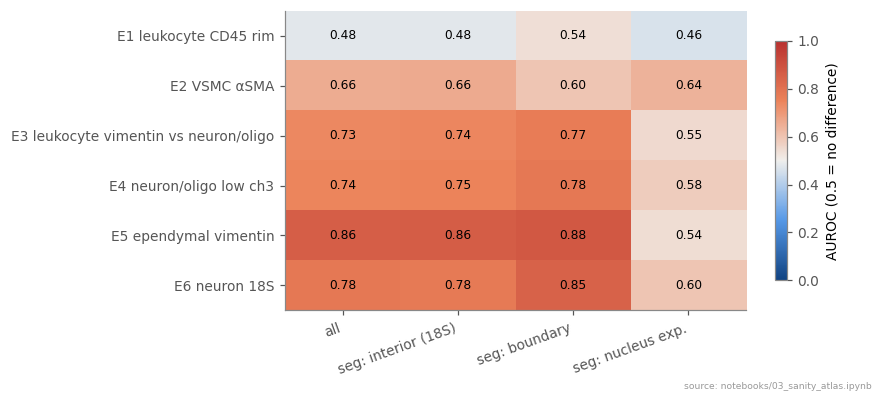

In [3]:
fig, ax = plt.subplots(figsize=(8, 3.6))
pv = res[~res.stratum.str.startswith("animals")].pivot(index="test", columns="stratum", values="auroc")
pv = pv[["all", "seg: interior (18S)", "seg: boundary", "seg: nucleus exp."]].loc[list(TESTS)]
im = ax.imshow(pv.values, cmap=plotting.DIV, vmin=0, vmax=1, aspect="auto")
for i in range(pv.shape[0]):
    for j in range(pv.shape[1]):
        if np.isfinite(pv.values[i, j]):
            ax.text(j, i, f"{pv.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_xticks(range(pv.shape[1]), pv.columns, rotation=20, ha="right")
ax.set_yticks(range(pv.shape[0]), pv.index)
fig.colorbar(im, ax=ax, label="AUROC (0.5 = no difference)", shrink=0.8)
fig.tight_layout()
plotting.save_fig(fig, "expectation_tests", OUT, SRC)

> **Finding — five of six expectations hold in every animal**: VSMC αSMA-bright (AUROC 0.66), leukocyte vimentin >
> neuron/oligo (0.73), neuron/oligo low in ch3 (0.74), ependymal vimentin (0.86), neuron 18S (0.78); 25/25 animals
> each, and they hold in *boundary*-segmented cells too (not an 18S-mask artefact). Nucleus-expansion cells lose most
> signal (their mask is a 5 µm guess). **E1 (CD45 at the leukocyte rim) fails: 0.48.**

### E1 follow-up: CD45 where the neuropil does not drown it
The boundary channel pools ATP1A1 (neuropil, high in GM/WM) with CD45. Restrict to cells whose local background
is in the lowest quartile of their section (meninges, lesion cores, roots) and compare leukocytes with
non-leukocytes *in that context*: background-subtracted cell mean and cell ÷ territory contrast.

,context,feature,auroc,n_leuko,n_other
0,all,bnd_cell_mean,0.545,130618,368328
1,all,bnd_cell_over_terr,0.478,130618,368328
2,all,bnd_rim_over_ring,0.477,130618,368328
3,all,bnd_cell_mean: Myeloid vs non-leuko,0.536,89946,368328
4,all,bnd_cell_mean: T cell vs non-leuko,0.556,16371,368328
5,all,bnd_cell_mean: B cell vs non-leuko,0.605,4635,368328
6,all,bnd_cell_mean: DC vs non-leuko,0.572,17449,368328
7,all,bnd_cell_mean: NK/DC vs non-leuko,0.524,2077,368328
8,all,bnd_cell_mean: Neutrophil vs non-leuko,0.644,140,368328
9,low-ATP1A1 context,bnd_cell_mean,0.464,37323,87417


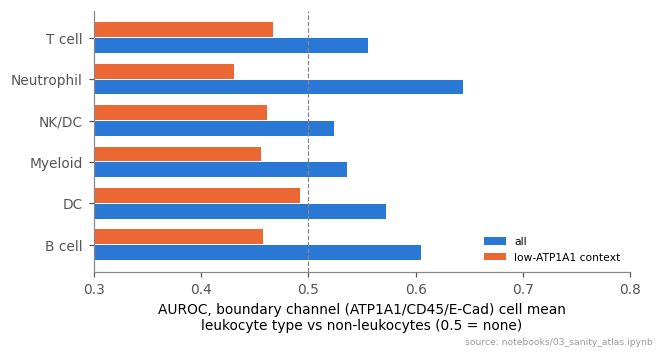

In [4]:
q25 = f.groupby("section_id").bnd_bg_local.transform(lambda s: s.quantile(0.25))
low = f.bnd_bg_local <= q25
f["bnd_cell_over_terr"] = (f.bnd_cell_mean + f.bnd_bg_local / f.bnd_scale) / \
                          (f.bnd_terr_mean + f.bnd_bg_local / f.bnd_scale)
isL = f.Anno_L1_curated.isin(LEUKO)
rows = []
for ctx, m in (("all", np.ones(len(f), bool)), ("low-ATP1A1 context", low.values)):
    for feat in ("bnd_cell_mean", "bnd_cell_over_terr", "bnd_rim_over_ring"):
        rows.append(dict(context=ctx, feature=feat, auroc=round(auroc(f.loc[isL & m, feat], f.loc[~isL & m, feat]), 3),
                         n_leuko=int((isL & m).sum()), n_other=int((~isL & m).sum())))
    for t in LEUKO:
        mt = (f.Anno_L1_curated == t) & m
        rows.append(dict(context=ctx, feature=f"bnd_cell_mean: {t} vs non-leuko",
                         auroc=round(auroc(f.loc[mt, "bnd_cell_mean"], f.loc[~isL & m, "bnd_cell_mean"]), 3),
                         n_leuko=int(mt.sum()), n_other=int((~isL & m).sum())))
e1 = pd.DataFrame(rows)
e1.to_csv(OUT / "E1_cd45_context.csv", index=False)
d = e1[e1.feature.str.startswith("bnd_cell_mean:")].copy()
d["type"] = d.feature.str.replace("bnd_cell_mean: ", "").str.replace(" vs non-leuko", "")
pv = d.pivot(index="type", columns="context", values="auroc")
fig, ax = plt.subplots(figsize=(6, 3.2))
y = np.arange(len(pv))
for k, ctx in enumerate(pv.columns):
    ax.barh(y + (k - 0.5) * 0.38, pv[ctx], height=0.36, color=plotting.CATEGORICAL[k], label=ctx)
ax.axvline(0.5, color="#888888", lw=0.8, ls="--")
ax.set_yticks(y, pv.index); ax.set_xlim(0.3, 0.8)
ax.set_xlabel("AUROC, boundary channel (ATP1A1/CD45/E-Cad) cell mean\nleukocyte type vs non-leukocytes (0.5 = none)")
ax.legend(fontsize=7, loc="lower right")
fig.tight_layout()
plotting.save_fig(fig, "E1_cd45_context", OUT, SRC)
e1

> **Finding — CD45 is not detectable.** Even where neuropil ATP1A1 is lowest (bottom quartile of local background per
> section — meninges, lesion cores, roots), every leukocyte type is *as dim or dimmer* than non-leukocytes (AUROC
> 0.41–0.49). In this mouse spinal cord the boundary channel behaves as ATP1A1 only. Worth asking 10x whether the kit's
> CD45 antibody is mouse-reactive. (*Ptprc* is on the panel, so CD45 RNA is available anyway.)

## Atlas: cell type × feature (normalised medians, z-scored across types)

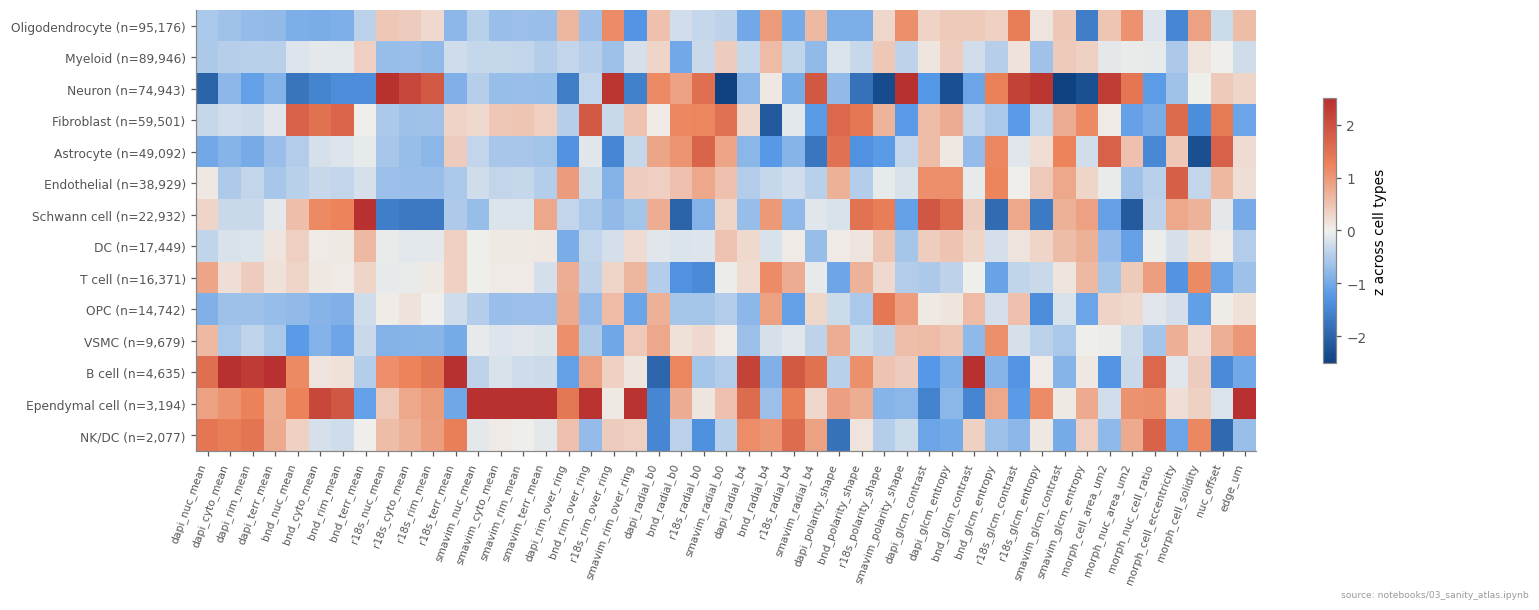

In [5]:
FEAT = ([f"{ch}_{c}_mean" for ch in CH for c in ("nuc", "cyto", "rim", "terr")]
        + [f"{ch}_rim_over_ring" for ch in CH]
        + [f"{ch}_radial_b0" for ch in CH] + [f"{ch}_radial_b4" for ch in CH]
        + [f"{ch}_polarity_shape" for ch in CH]
        + [f"{ch}_glcm_{k}" for ch in CH for k in ("contrast", "entropy")]
        + ["morph_cell_area_um2", "morph_nuc_area_um2", "morph_nuc_cell_ratio", "morph_cell_eccentricity",
           "morph_cell_solidity", "nuc_offset", "edge_um"])
med = f.groupby("Anno_L1_curated", observed=True)[FEAT].median().loc[TYPES]
z = (med - med.mean()) / med.std()
fig, ax = plt.subplots(figsize=(14, 5.5))
im = ax.imshow(z.values, cmap=plotting.DIV, vmin=-2.5, vmax=2.5, aspect="auto")
ax.set_xticks(range(len(FEAT)), FEAT, rotation=70, ha="right", fontsize=7)
ax.set_yticks(range(len(TYPES)), [f"{t} (n={n[t]:,})" for t in TYPES], fontsize=8)
fig.colorbar(im, ax=ax, label="z across cell types", shrink=0.6)
fig.tight_layout()
plotting.save_fig(fig, "atlas_celltype_heatmap", OUT, SRC)
med.to_csv(OUT / "atlas_celltype_medians.csv")

## Same atlas, per segmentation method
If the cell-type pattern is a property of the cells (not of how the mask was drawn), the three panels agree.

between-type pattern correlation with all cells (each stratum centred on its own mean): {'interior (18S)': np.float64(0.998), 'boundary': np.float64(0.626), 'nucleus exp.': np.float64(0.304)}


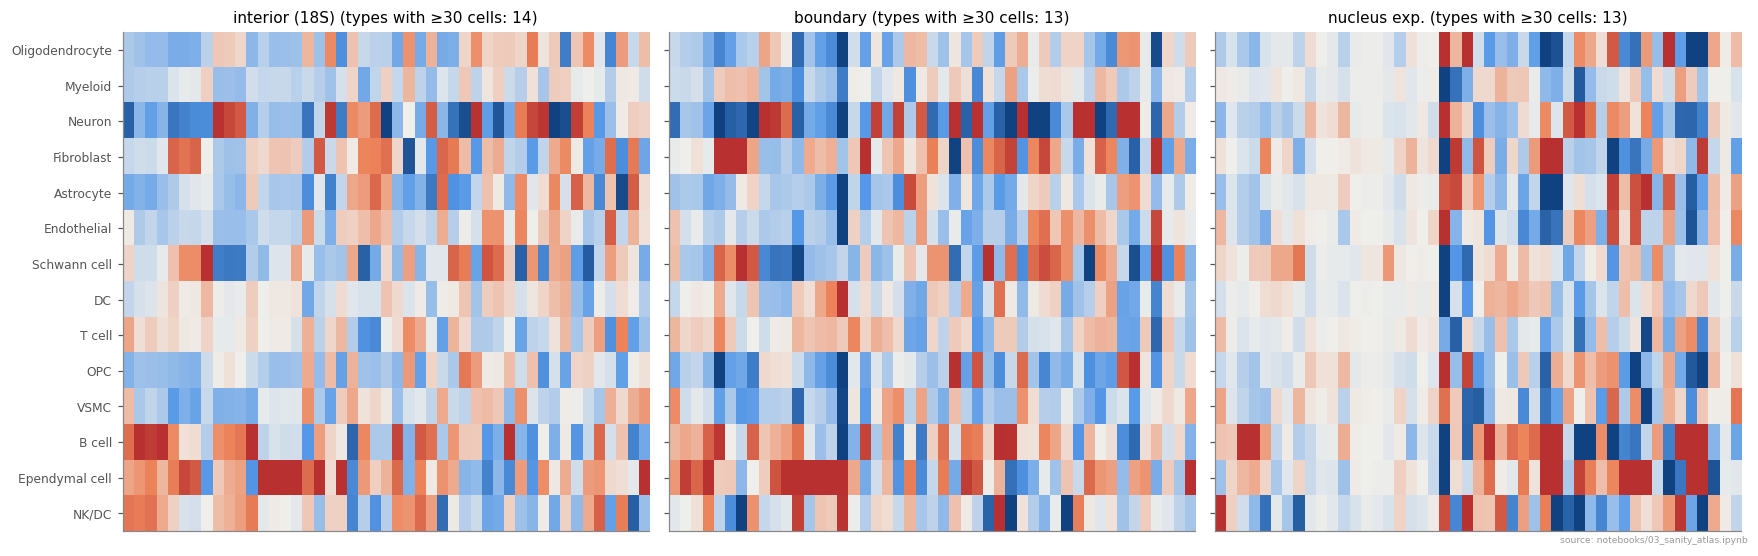

In [6]:
segs = ["interior (18S)", "boundary", "nucleus exp."]
fig, axs = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
corr, offset = {}, {}
for ax, s in zip(axs, segs):
    sub = f[f.seg == s]
    cnt = sub.Anno_L1_curated.value_counts()
    keep = [t for t in TYPES if cnt.get(t, 0) >= 30]
    m_ = sub.groupby("Anno_L1_curated", observed=True)[FEAT].median().reindex(TYPES)
    zs = (m_ - m_.loc[keep].mean()) / med.std()          # centred within stratum: between-type pattern only
    offset[s] = ((m_.loc[keep].mean() - med.loc[keep].mean()) / med.std())
    ax.imshow(zs.values, cmap=plotting.DIV, vmin=-2.5, vmax=2.5, aspect="auto")
    ax.set_title(f"{s} (types with ≥30 cells: {len(keep)})")
    ax.set_xticks([])
    zk = z.loc[keep] - z.loc[keep].mean()
    corr[s] = np.corrcoef(zs.loc[keep].values.ravel(), zk.values.ravel())[0, 1]
axs[0].set_yticks(range(len(TYPES)), TYPES, fontsize=8)
fig.tight_layout()
plotting.save_fig(fig, "atlas_by_segmethod", OUT, SRC)
print("between-type pattern correlation with all cells (each stratum centred on its own mean):",
      {k: round(v, 3) for k, v in corr.items()})

The removed per-stratum offsets = the segmentation-method main effect on each feature (in SD units of the
between-type spread). Largest offsets:

In [7]:
off = pd.DataFrame(offset)
off.reindex(off.abs().max(axis=1).sort_values(ascending=False).index).head(15).round(2)

,interior (18S),boundary,nucleus exp.
bnd_radial_b4,-0.03,10.18,-3.14
morph_cell_solidity,-0.22,6.41,6.28
r18s_glcm_entropy,0.08,-1.55,-6.00
morph_cell_eccentricity,0.12,-2.48,-5.64
nuc_offset,0.17,-2.56,-5.56
r18s_radial_b0,-0.02,-2.18,5.30
smavim_radial_b4,-0.03,4.97,-2.16
dapi_radial_b0,-0.00,-1.12,4.83
bnd_radial_b0,0.06,-4.51,1.08
bnd_rim_mean,-0.04,4.50,-0.26


> **Finding — segmentation method shifts shape/distribution features for all cell types alike** (boundary-segmented:
> boundary stain at the outer radial bin +10 SD, solidity +6 SD — the stain drew that edge). After removing these
> offsets the cell-type pattern holds for boundary cells (r = 0.63) but only weakly for nucleus-expansion cells
> (r = 0.30). → Downstream analyses use 18S-segmented cells (96 %); 18S *distribution* features are partly by
> construction.

## Violins: key features by cell type, split by segmentation method

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/03_sanity_atlas/violins_key_features.png')

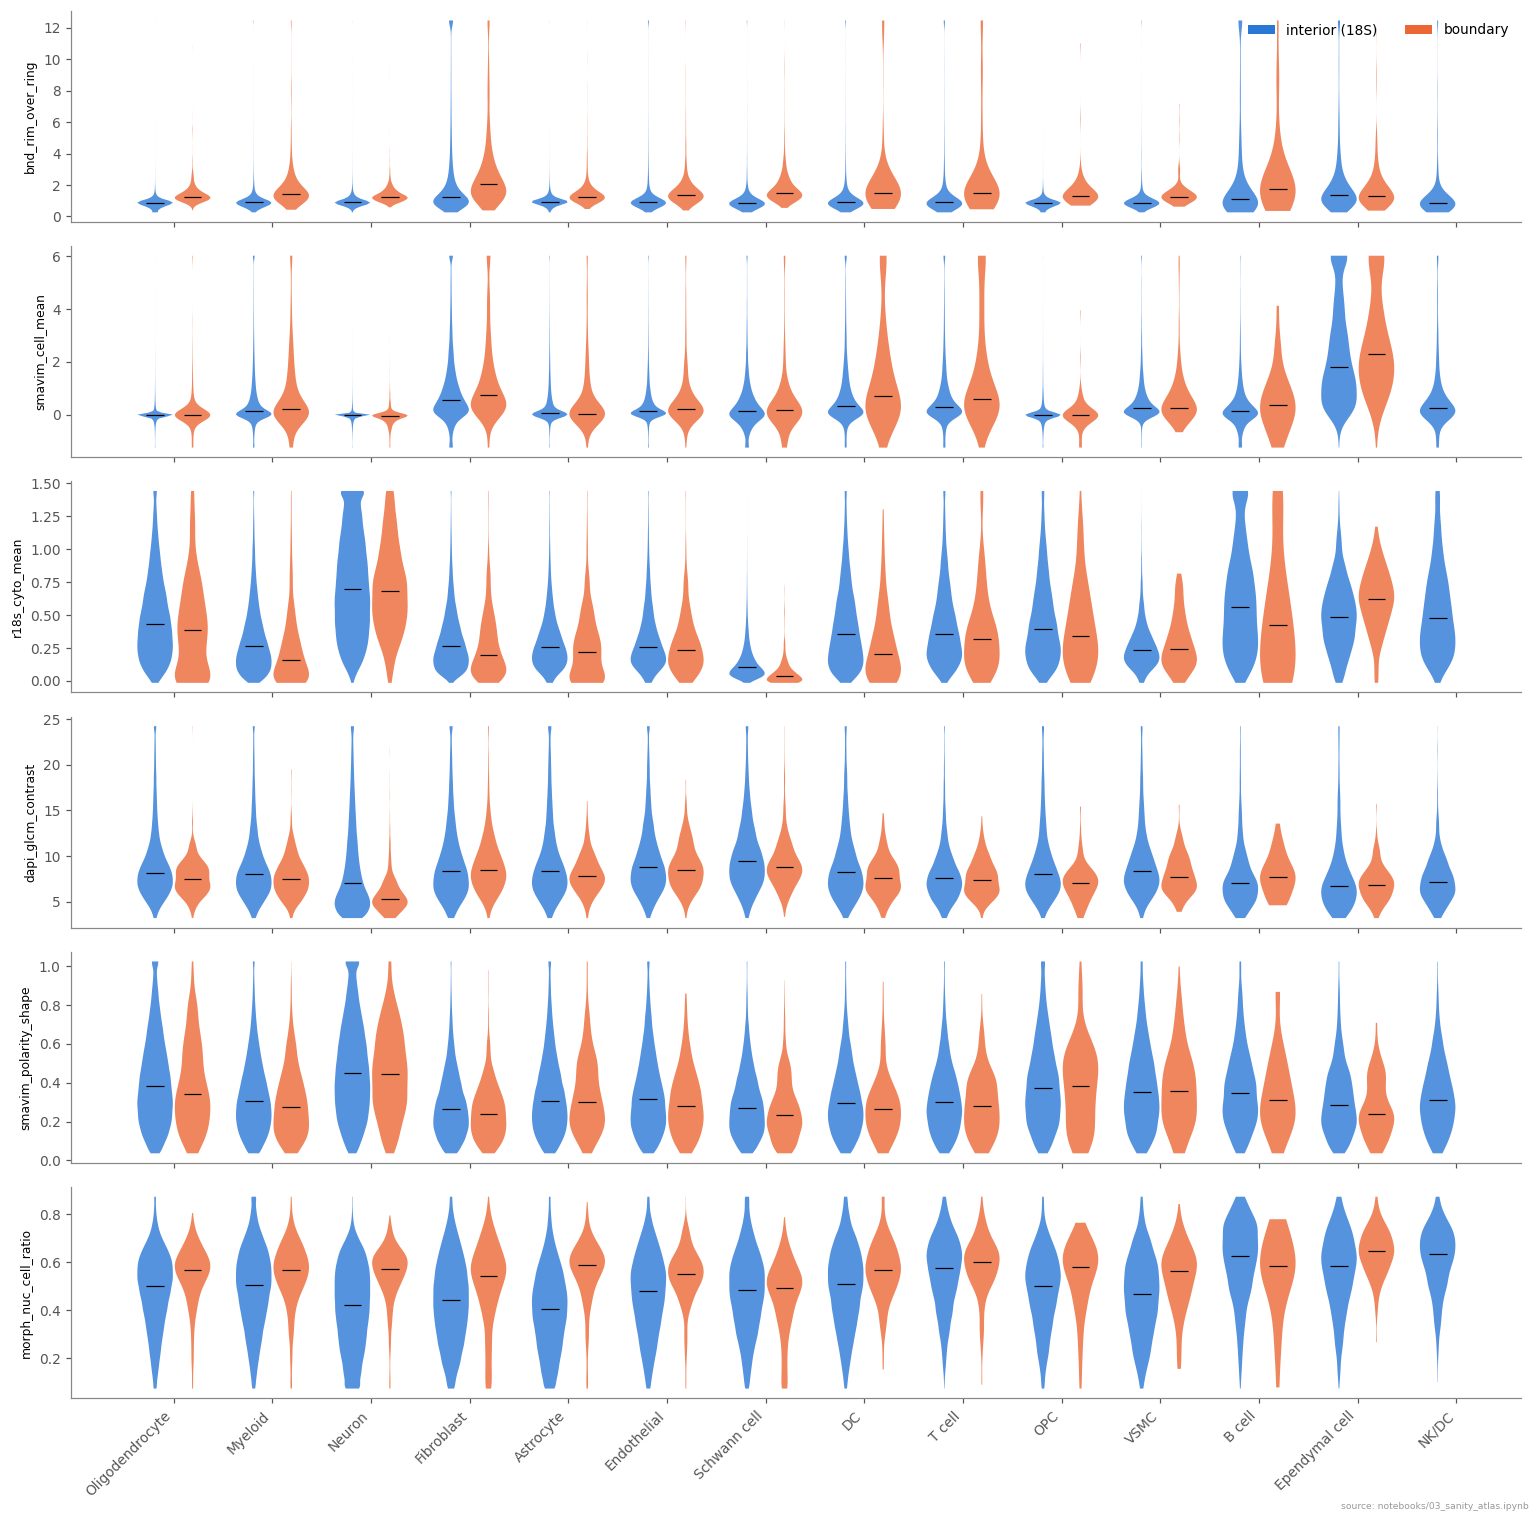

In [8]:
KEY = ["bnd_rim_over_ring", "smavim_cell_mean", "r18s_cyto_mean", "dapi_glcm_contrast",
       "smavim_polarity_shape", "morph_nuc_cell_ratio"]
fig, axs = plt.subplots(len(KEY), 1, figsize=(14, 2.3 * len(KEY)), sharex=True)
for ax, feat in zip(axs, KEY):
    lo, hi = np.nanpercentile(f[feat], [1, 99])
    for k, s in enumerate(["interior (18S)", "boundary"]):
        vals, pos = [], []
        for i, t in enumerate(TYPES):
            v = f.loc[(f.Anno_L1_curated == t) & (f.seg == s), feat].dropna().clip(lo, hi)
            if len(v) >= 20:
                vals.append(v.values); pos.append(i + (k - 0.5) * 0.38)
        vp = ax.violinplot(vals, positions=pos, widths=0.36, showextrema=False, showmedians=True)
        for b in vp["bodies"]:
            b.set(facecolor=plotting.CATEGORICAL[k], edgecolor="none", alpha=0.8)
        vp["cmedians"].set(color="black", lw=0.8)
    ax.set_ylabel(feat, fontsize=8)
axs[-1].set_xticks(range(len(TYPES)), TYPES, rotation=45, ha="right")
axs[0].legend([plt.Rectangle((0, 0), 1, 1, fc=plotting.CATEGORICAL[k]) for k in range(2)],
              ["interior (18S)", "boundary"], ncol=2, loc="upper right")
fig.tight_layout()
plotting.save_fig(fig, "violins_key_features", OUT, SRC)

> **Finding — the violins show the key contrasts per cell type and that boundary-segmented cells follow the same
> ordering as 18S-segmented ones** for vimentin, 18S and nucleus:cell ratio; the boundary-channel rim/ring ratio is flat
> across types (no CD45 rim).

## Cell type × lesion state
log2 fold change (lesion niches vs physiological niche) of the normalised median, per cell type.
Intensities are background-subtracted so can be ≤ 0; fold changes use the ratio of medians shifted by the
feature's global 5th percentile.

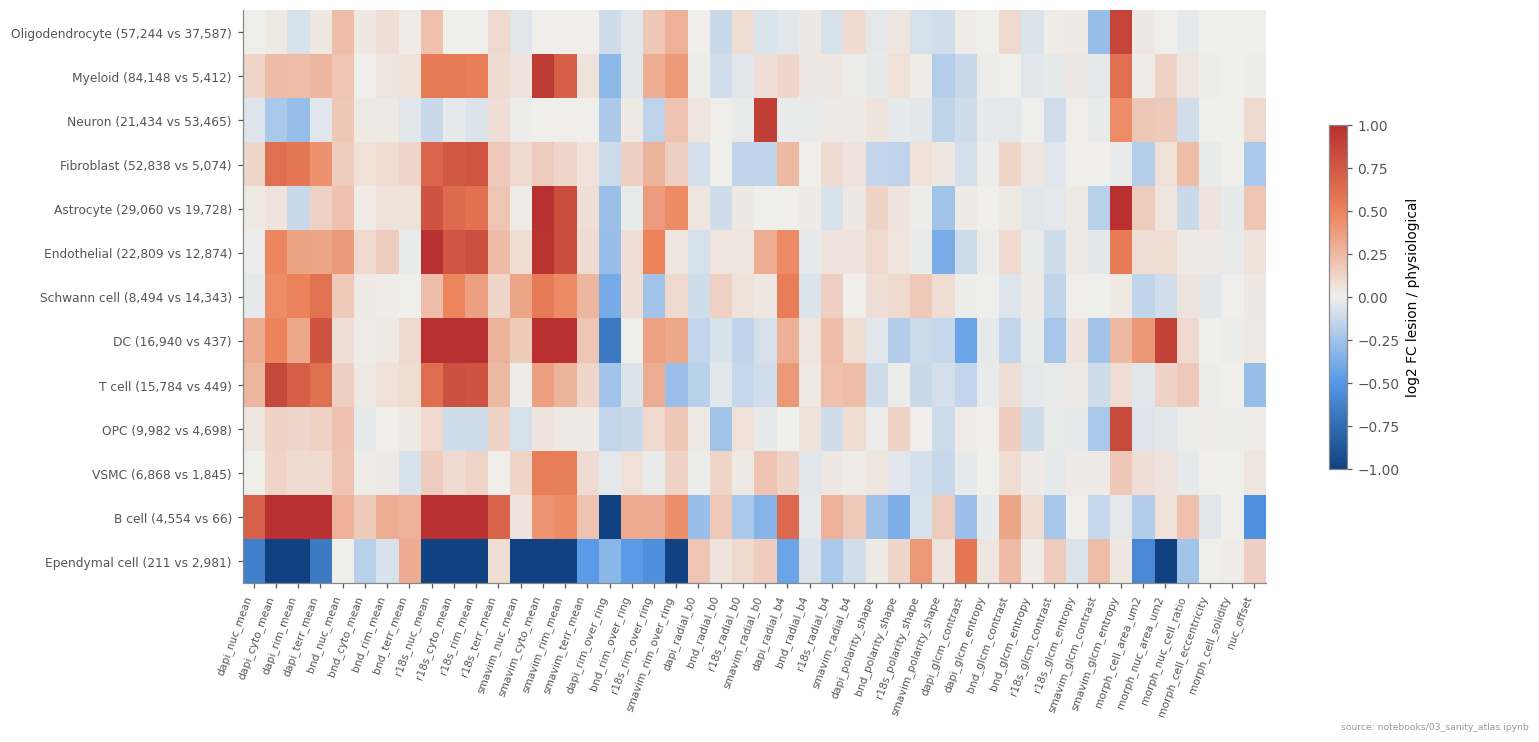

In [9]:
FC_FEAT = [c for c in FEAT if c != "edge_um"]
rows = {}
for t in TYPES:
    a = f[(f.Anno_L1_curated == t) & f.lesion]
    b = f[(f.Anno_L1_curated == t) & (f.Curated_niche_state == "Physiological")]
    if len(a) < 50 or len(b) < 50:
        continue
    off = f[FC_FEAT].quantile(0.05)
    sh = (off < 0) * (-off) + 1e-3
    rows[f"{t} ({len(a):,} vs {len(b):,})"] = np.log2((a[FC_FEAT].median() + sh) / (b[FC_FEAT].median() + sh))
fc = pd.DataFrame(rows).T
fig, ax = plt.subplots(figsize=(14, 0.4 * len(fc) + 1.5))
im = ax.imshow(fc.values, cmap=plotting.DIV, vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(FC_FEAT)), FC_FEAT, rotation=70, ha="right", fontsize=7)
ax.set_yticks(range(len(fc)), fc.index, fontsize=8)
fig.colorbar(im, ax=ax, label="log2 FC lesion / physiological", shrink=0.6)
fig.tight_layout()
plotting.save_fig(fig, "lesion_vs_physiological_fc", OUT, SRC)
fc.to_csv(OUT / "lesion_vs_physiological_log2fc.csv")

> **Finding — lesion vs physiological, per cell type:** astrocyte αSMA/Vim cytoplasm is **~2× higher in lesions**
> (log2 FC 1.07) — vimentin up in reactive astrocytes, as expected. Large changes in DC and B cells rest on tiny
> physiological groups (437 and 66 cells) and ependymal lesion cells are few (211) — treat those as unreliable.